In [21]:
# yprop_pipeline.ipynb (Jupyter Notebook style as .py for clarity)

# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
from tpot import TPOTRegressor

In [22]:

# Cell 2: Load the dataset (Fold 1 of yprop_4_1)
X = pd.read_parquet("data/yprop_4_1/1/X_train.parquet")
y = pd.read_parquet("data/yprop_4_1/1/y_train.parquet").values.ravel()

array([0.902078, 0.911472, 0.879133, ..., 0.93234 , 0.924571, 0.903252])

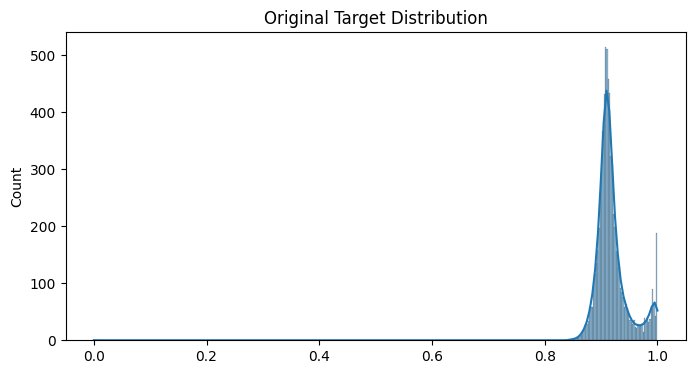

In [65]:


# Cell 3: Visualize and transform target distribution
plt.figure(figsize=(8, 4))
sns.histplot(y, kde=True)
plt.title("Original Target Distribution")
# plt.show()

y_log = np.log1p(y)
y

In [24]:

# Cell 4: Preprocessing
X = X.fillna(X.median(numeric_only=True))
X = pd.get_dummies(X, drop_first=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
# Cell 5: TPOT Feature Engineering
import os
os.environ["TPOT_USE_DASK"] = "False"

from tpot import TPOTRegressor

tpot = TPOTRegressor(
    generations=2,
    population_size=10,
    random_state=42,
    n_jobs=1,
    max_time_mins=3,

)
tpot.fit(X_scaled, y_log)
#tpot.export("best_pipeline.py")




/opt/miniconda3/envs/automl-tabular-env/lib/python3.11/site-packages/tpot/tpot_estimator/estimator.py:458: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.
  warnings.warn("Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.")
/opt/miniconda3/envs/automl-tabular-env/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 51705 instead
  warnings.warn(

Generation:  50%|███████████████████████████████▌                               | 1/2 [06:21<06:21, 381.40s/it]


AttributeError: 'TPOTRegressor' object has no attribute 'export'

In [39]:
# Extract features if pipeline includes a transformer
pipeline = tpot.fitted_pipeline_
X_tpot = pipeline[:-1].transform(X_scaled) if hasattr(pipeline, "transform") else X_scaled
X_tpot

array([[ 4.42784298e-02,  5.33749594e-01,  2.01890855e-02, ...,
        -3.91275771e-02,  0.00000000e+00, -6.89004884e-02],
       [ 2.70543688e-02, -2.21930216e+00, -8.40064661e-02, ...,
        -3.91275771e-02,  0.00000000e+00, -6.89004884e-02],
       [ 8.15882297e-02,  4.79059565e-01,  5.50914688e-02, ...,
        -3.91275771e-02,  0.00000000e+00, -6.89004884e-02],
       ...,
       [ 6.24203875e-02,  4.79059565e-01,  4.80427790e-02, ...,
        -3.91275771e-02,  0.00000000e+00, -6.89004884e-02],
       [ 6.90616399e-02,  4.79059565e-01,  4.90091317e-02, ...,
        -3.91275771e-02,  0.00000000e+00, -6.89004884e-02],
       [ 1.08329245e-03,  4.79059565e-01, -1.76692000e-02, ...,
        -3.91275771e-02,  0.00000000e+00, -6.89004884e-02]])

In [36]:
# Cell 6: Train-test split
X_train, X_val, y_train, y_val = train_test_split(X_tpot, y_log, test_size=0.2, random_state=42)

In [37]:
# Cell 7: Hyperparameter Tuning (Grid Search)
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.3],
    "subsample": [0.8, 1.0]
}

xgb = XGBRegressor(random_state=42)
grid = GridSearchCV(
    xgb,
    param_grid,
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1
)
grid.fit(X_train, y_train)



Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.3],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200],
                         'subsample': [0.8, 1.0]},
             scoring='r2', verbose=1)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
R^2 Score (log target): 0.02991675794087323
R^2 Score (original scale): 0.04120397061119663


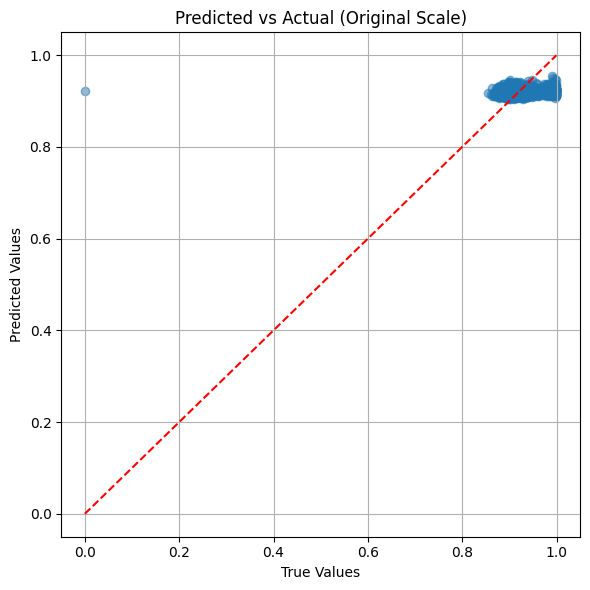

In [38]:
# Cell 8: Evaluate and plot
y_pred_log = grid.predict(X_val)
y_pred = np.expm1(y_pred_log)
y_val_orig = np.expm1(y_val)

print("Best Parameters:", grid.best_params_)
print("R^2 Score (log target):", r2_score(y_val, y_pred_log))
print("R^2 Score (original scale):", r2_score(y_val_orig, y_pred))

plt.figure(figsize=(6, 6))
plt.scatter(y_val_orig, y_pred, alpha=0.5)
plt.plot([y_val_orig.min(), y_val_orig.max()], [y_val_orig.min(), y_val_orig.max()], 'r--')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual (Original Scale)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [51]:
xgb_r2 = r2_score(y_val_orig, y_pred)
xgb_r2

0.04120397061119663

In [43]:
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
import lightgbm as lgb


In [44]:
# Cell 7: Individual Models with R2 scoring

# Gradient Boosting Regressor
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_val)
gb_r2 = r2_score(y_val, gb_pred)
print(f"Gradient Boosting R2: {gb_r2:.4f}")

# LightGBM
lgb_model = lgb.LGBMRegressor(random_state=42)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_val)
lgb_r2 = r2_score(y_val, lgb_pred)
print(f"LightGBM R2: {lgb_r2:.4f}")

# CatBoost
cat_model = CatBoostRegressor(random_state=42, verbose=0)
cat_model.fit(X_train, y_train)
cat_pred = cat_model.predict(X_val)
cat_r2 = r2_score(y_val, cat_pred)
print(f"CatBoost R2: {cat_r2:.4f}")

Gradient Boosting R2: 0.0240


/opt/miniconda3/envs/automl-tabular-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM R2: 0.0217
CatBoost R2: 0.0232


In [52]:
   # Cell 8: Weighted Ensemble
# Calculate weights based on R2 scores (higher R2 gets more weight)
weights = np.array([xgb_r2,gb_r2, lgb_r2, cat_r2])
weights = weights / weights.sum()  # Normalize to sum to 1

weighted_pred = (gb_pred * weights[0] + lgb_pred * weights[1] + cat_pred * weights[2])
weighted_r2 = r2_score(y_val, weighted_pred)
print(f"\nWeighted Ensemble R2: {weighted_r2:.4f}")
print(f"Model weights: Gradient Boosting: {weights[0]:.2f}, LightGBM: {weights[1]:.2f}, CatBoost: {weights[2]:.2f}")

# Cell 9: Stacking Ensemble
# Create a stacking ensemble with Linear Regression as the meta-model
estimators = [
    ('gb', GradientBoostingRegressor(random_state=42)),
    ('lgb', lgb.LGBMRegressor(random_state=42)),
    ('cat', CatBoostRegressor(random_state=42, verbose=0))
]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(),
    cv=5
)

stacking_model.fit(X_train, y_train)
stacking_pred = stacking_model.predict(X_val)
stacking_r2 = r2_score(y_val, stacking_pred)
print(f"\nStacking Ensemble R2: {stacking_r2:.4f}")


Weighted Ensemble R2: -36.3314
Model weights: Gradient Boosting: 0.37, LightGBM: 0.22, CatBoost: 0.20


/opt/miniconda3/envs/automl-tabular-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/automl-tabular-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/automl-tabular-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/automl-tabular-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/automl-tabular-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not h


Stacking Ensemble R2: 0.0319


/opt/miniconda3/envs/automl-tabular-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [53]:
print("\nModel Comparison:")
print(f"Gradient Boosting R2: {gb_r2:.4f}")
print(f"LightGBM R2: {lgb_r2:.4f}")
print(f"CatBoost R2: {cat_r2:.4f}")
print(f"Weighted Ensemble R2: {weighted_r2:.4f}")
print(f"Stacking Ensemble R2: {stacking_r2:.4f}")


Model Comparison:
Gradient Boosting R2: 0.0240
LightGBM R2: 0.0217
CatBoost R2: 0.0232
Weighted Ensemble R2: -36.3314
Stacking Ensemble R2: 0.0319


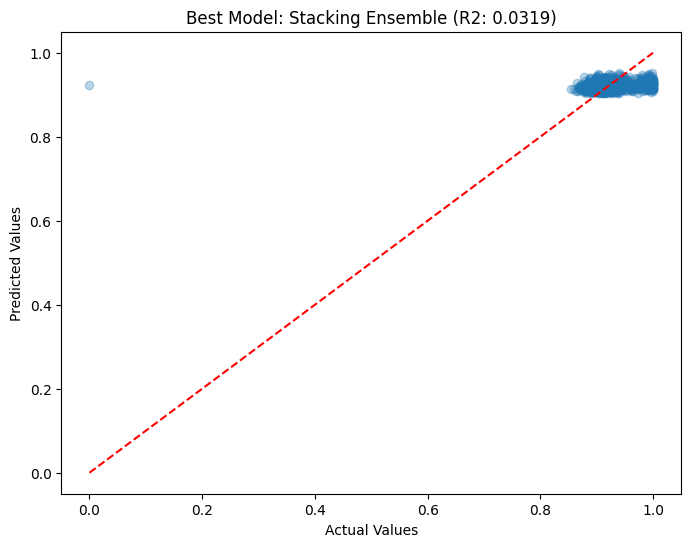

In [47]:
best_model_name = np.argmax([gb_r2, lgb_r2, cat_r2, weighted_r2, stacking_r2])
best_model_names = ['Gradient Boosting', 'LightGBM', 'CatBoost', 'Weighted Ensemble', 'Stacking Ensemble']
best_pred = [gb_pred, lgb_pred, cat_pred, weighted_pred, stacking_pred][best_model_name]

plt.figure(figsize=(8, 6))
plt.scatter(np.expm1(y_val), np.expm1(best_pred), alpha=0.3)
plt.plot([min(np.expm1(y_val)), max(np.expm1(y_val))], 
         [min(np.expm1(y_val)), max(np.expm1(y_val))], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Best Model: {best_model_names[best_model_name]} (R2: {r2_score(y_val, best_pred):.4f})')
plt.show()